# Cold Start Strategy Evaluation

## Purpose
Evaluate and compare different cold start strategies before any model training.
The goal is to assess diversity, representativeness, and informativeness of
initial labeled samples.

## Strategies Tested
- Random
- Simple diversity (image statistics)
- Deep feature diversity
- Entropy-based uncertainty
- Weak supervision
- Self-supervised features

## Outputs
- Selected sample indices
- Diversity statistics
- Feature-space coverage plots


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append(str(Path("..").resolve()))

from src.cold_start_strategies import ColdStartStrategies
from src.data_modules.factory import load_dataset
from config.config import ActiveLearningConfig


Data modules package initialized.


In [17]:
config = ActiveLearningConfig.from_yaml("../experiments/configs/example_segmentation.yaml")
dataset = load_dataset(config, split="train")

all_indices = list(range(len(dataset)))
config.initial_labeled = 0.15 # e.g. 15%
n_samples = int(config.initial_labeled * len(dataset))  

[DeepCrack] 300 samples loaded for split='train'


In [5]:
config.dataset

'DeepCrack'

In [6]:
cold_start = ColdStartStrategies(dataset, config)

strategies = [
    "random",
    "simple_diversity",
    "diversity",
    "entropy_based_uncertainty",
    "weak_supervision",
    "self_supervised",
]

selections = {}

for s in strategies:
    selected = cold_start.apply(s, n_samples, all_indices)
    selections[s] = selected
    print(f"{s}: selected {len(selected)} samples")


Applying cold start strategy: random
random: selected 45 samples
Applying cold start strategy: simple_diversity
simple_diversity: selected 45 samples
Applying cold start strategy: diversity


/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


diversity: selected 45 samples
Applying cold start strategy: entropy_based_uncertainty
entropy_based_uncertainty: selected 45 samples
Applying cold start strategy: weak_supervision
Using weak supervision sampling...
weak_supervision: selected 45 samples
Applying cold start strategy: self_supervised
Using self-supervised sampling...


Using cache found in /home3/vzcl68/.cache/torch/hub/facebookresearch_semi-supervised-ImageNet1K-models_master
/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


self_supervised: selected 45 samples


In [12]:
def compute_diversity(features):
    dists = []
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            dists.append(np.linalg.norm(features[i] - features[j]))
    return np.mean(dists)

def label_histogram(indices):
    labels = []
    for i in indices:
        _, mask = dataset[i]
        labels.append(mask.unique().cpu().numpy())
    return np.unique(np.concatenate(labels), return_counts=True)


In [13]:
features_all = cold_start._extract_features(all_indices)

features_selected = {
    s: features_all[[all_indices.index(i) for i in idxs]]
    for s, idxs in selections.items()
}

/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
import pandas as pd

rows = []
for s, feats in features_selected.items():
    rows.append({
        "strategy": s,
        "diversity": compute_diversity(feats),
        "coverage": compute_diversity(feats) / compute_diversity(features_all),
    })

df = pd.DataFrame(rows)
df.sort_values("coverage", ascending=False)


,strategy,diversity,coverage
3,entropy_based_uncertainty,17.571840,1.158414
4,weak_supervision,17.041948,1.123481
1,simple_diversity,16.073210,1.059618
5,self_supervised,15.741774,1.037768
2,diversity,15.292564,1.008154
0,random,15.121483,0.996876


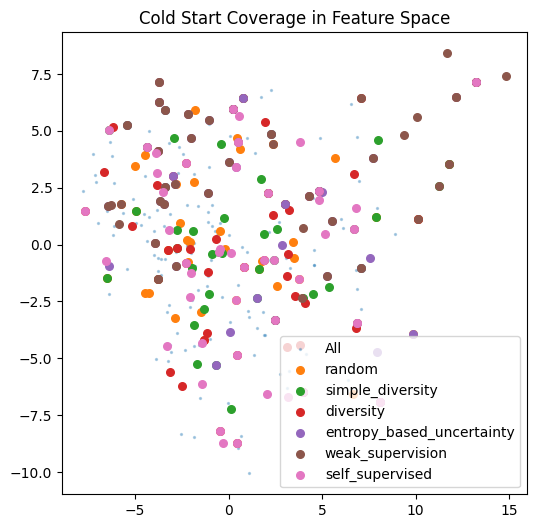

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
proj_all = pca.fit_transform(features_all)

plt.figure(figsize=(6,6))
plt.scatter(proj_all[:,0], proj_all[:,1], s=2, alpha=0.3, label="All")

for s, feats in features_selected.items():
    proj_sel = pca.transform(feats)
    plt.scatter(proj_sel[:,0], proj_sel[:,1], label=s, s=30)

plt.legend()
plt.title("Cold Start Coverage in Feature Space")
plt.show()


In [18]:
import json

with open(f"results/cold_start_selections_{config.dataset}_{config.initial_labeled}.json", "w") as f:
    json.dump(selections, f, indent=2)